# 🎮 Análise do Dataset Video Game Sales 2024 - Atividade 03
Este notebook reúne etapas de exploração, organização e análise estatística do conjunto de dados sobre vendas globais de jogos de videogame **até 2024**.

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [69]:
url = 'https://raw.githubusercontent.com/gilgameshr3rr/projeto-estatistica/project-edition-larissa/dataset/vgchartz-2024.csv'
df = pd.read_csv(url)
df.head()

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14


## 📊 1. Como se distribuem as vendas globais entre os 100 jogos mais vendidos?

🎮 Esta análise considera os 100 jogos com maior volume de vendas globais e os classifica em faixas de vendas.  
O objetivo é entender como esses jogos estão distribuídos de acordo com o total vendido, identificando quantos se concentram em faixas mais altas ou mais baixas de desempenho comercial.


### 📊 Distribuição dos Jogos por Faixa de Vendas

,Faixa de Vendas,Quantidade de Jogos
0,0–5 mi,9
1,5–10 mi,69
2,10–20 mi,21
3,20+ mi,1


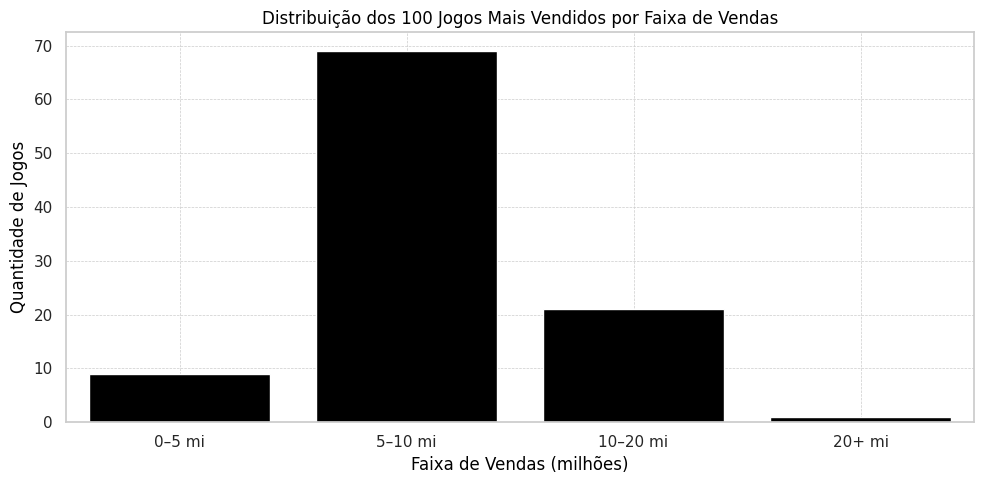


### 🔎 Análise

A classificação dos 100 jogos mais vendidos em faixas de vendas revela uma **concentração significativa nas categorias intermediárias**.  
A maioria dos títulos se encontra nas faixas de **5 a 10 milhões** (69 jogos) e **10 a 20 milhões de unidades vendidas** (21 jogos), indicando que esse é o intervalo mais comum entre os grandes sucessos comerciais.

A faixa **acima de 20 milhões** (1 jogos) representa um grupo mais restrito, composto por poucos jogos que atingiram vendas extraordinárias — geralmente pertencentes a franquias mundialmente populares.  
Já a faixa **de 0 a 5 milhões** (9 jogos), apesar de conter títulos de alto desempenho, representa a parte inferior do Top 100, mostrando que estar entre os mais vendidos não exige necessariamente atingir os maiores patamares.

Essa distribuição reforça que, dentro do grupo de elite, **existe uma faixa recorrente de desempenho de vendas**, com poucos jogos ultrapassando os extremos. O gráfico de barras deixa esse padrão visualmente evidente.


In [68]:
# Seleciona os 100 jogos mais vendidos
top100 = df.sort_values(by='total_sales', ascending=False).head(100)

# Define as faixas de vendas (em milhões)
faixas = [0, 5, 10, 20, float('inf')]
rotulos = ['0–5 mi', '5–10 mi', '10–20 mi', '20+ mi']

# Cria nova coluna com as faixas
top100['faixa_vendas'] = pd.cut(top100['total_sales'], bins=faixas, labels=rotulos, right=False)

# Conta quantos jogos há em cada faixa
distribuicao = top100['faixa_vendas'].value_counts(sort=False).reset_index()
distribuicao.columns = ['Faixa de Vendas', 'Quantidade de Jogos']

# Exibe a tabela
display(Markdown("### 📊 Distribuição dos Jogos por Faixa de Vendas"))
display(distribuicao)

# Gráfico
sns.set_palette("gray")
sns.barplot(x='Faixa de Vendas', y='Quantidade de Jogos', data=distribuicao, color='black')
plt.title('Distribuição dos 100 Jogos Mais Vendidos por Faixa de Vendas', color='black')
plt.xlabel('Faixa de Vendas (milhões)', color='black')
plt.ylabel('Quantidade de Jogos', color='black')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

# Extrai as quantidades para cada faixa
q_0_5 = int(distribuicao.loc[distribuicao['Faixa de Vendas'] == '0–5 mi', 'Quantidade de Jogos'].values[0])
q_5_10 = int(distribuicao.loc[distribuicao['Faixa de Vendas'] == '5–10 mi', 'Quantidade de Jogos'].values[0])
q_10_20 = int(distribuicao.loc[distribuicao['Faixa de Vendas'] == '10–20 mi', 'Quantidade de Jogos'].values[0])
q_20_plus = int(distribuicao.loc[distribuicao['Faixa de Vendas'] == '20+ mi', 'Quantidade de Jogos'].values[0])

# Análise
texto = f"""
### 🔎 Análise

A classificação dos 100 jogos mais vendidos em faixas de vendas revela uma **concentração significativa nas categorias intermediárias**.
A maioria dos títulos se encontra nas faixas de **5 a 10 milhões** ({q_5_10} jogos) e **10 a 20 milhões de unidades vendidas** ({q_10_20} jogos), indicando que esse é o intervalo mais comum entre os grandes sucessos comerciais.

A faixa **acima de 20 milhões** ({q_20_plus} jogos) representa um grupo mais restrito, composto por poucos jogos que atingiram vendas extraordinárias — geralmente pertencentes a franquias mundialmente populares.
Já a faixa **de 0 a 5 milhões** ({q_0_5} jogos), apesar de conter títulos de alto desempenho, representa a parte inferior do Top 100, mostrando que estar entre os mais vendidos não exige necessariamente atingir os maiores patamares.

Essa distribuição reforça que, dentro do grupo de elite, **existe uma faixa recorrente de desempenho de vendas**, com poucos jogos ultrapassando os extremos. O gráfico de barras deixa esse padrão visualmente evidente.
"""

display(Markdown(texto))



## 📊 2. Quais gêneros de jogos, no conjunto completo do dataset, apresentam a maior média de vendas por jogo?

🎮 Esta análise considera todos os jogos disponíveis no conjunto de dados. A partir do agrupamento por gênero, é calculada a média de vendas globais por jogo, permitindo identificar quais estilos de jogos têm, em média, melhor desempenho comercial.

Esse panorama revela as preferências predominantes do mercado em termos de categorias de jogos, como ação, esportes, aventura, entre outros.


### 📊 Média de Vendas Globais por Gênero (todos os jogos)

,genre,total_sales
0,Sandbox,1.890000
1,Shooter,0.670370
2,Action-Adventure,0.562576
3,Sports,0.457262
4,Action,0.396580
5,Fighting,0.391653
6,Racing,0.367400
7,Platform,0.367140
8,Music,0.352041
9,MMO,0.310333


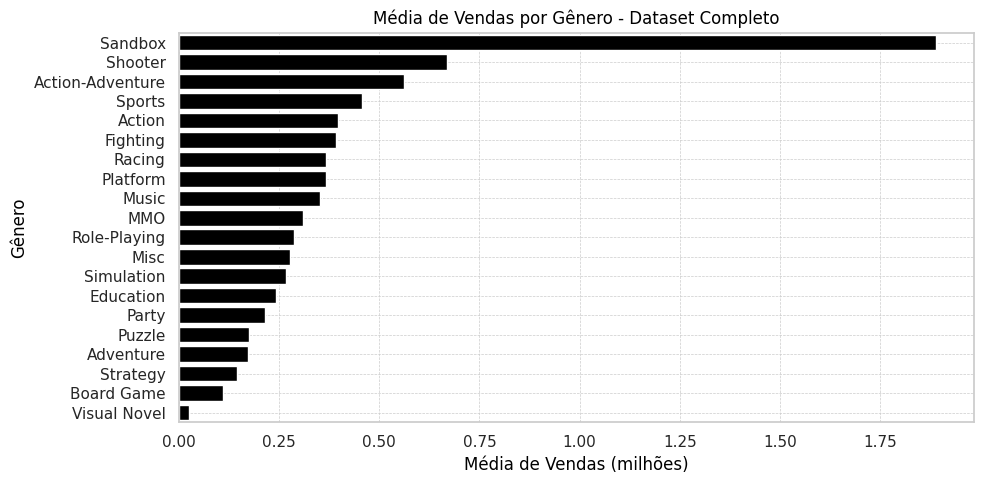


### 🔎 Análise

Os dados mostram que o gênero **Sandbox** lidera com uma média de vendas globais de aproximadamente **1,89 milhões por jogo**, seguido pelo gênero **Shooter**, com cerca de **670 mil**, e por **Action-Adventure**, que ocupa a terceira posição com uma média de **563 mil** por jogo.

Na outra extremidade da lista, o gênero **Visual Novel** apresenta a menor média de vendas globais, com cerca de **27 mil** por jogo, indicando menor desempenho comercial médio dentro do conjunto analisado.

Esses resultados indicam que gêneros como **Sandbox**, **Shooter** e **Action-Adventure** tendem a ter **maior apelo comercial médio**, se destacando no mercado em termos de consistência de vendas por jogo, enquanto outros estilos apresentam menor regularidade de sucesso.


In [64]:
# 📊 Pergunta 2 - Análise de Vendas por Gênero

# Estilo gráfico
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Função para formatar os valores
def formatar_vendas(valor):
    if valor < 1:
        return f"{valor * 1000:.0f} mil"
    else:
        return f"{valor:.2f}".replace('.', ',') + " milhões"

# Agrupamento por gênero
genero_media = df.groupby('genre')['total_sales'].mean().sort_values(ascending=False).reset_index()

# Exibe a tabela
display(Markdown("### 📊 Média de Vendas Globais por Gênero (todos os jogos)"))
display(genero_media)

# Gráfico em preto e branco
sns.set_palette("gray")
sns.barplot(x='total_sales', y='genre', data=genero_media, color='black')
plt.xlabel('Média de Vendas (milhões)', color='black')
plt.ylabel('Gênero', color='black')
plt.title('Média de Vendas por Gênero - Dataset Completo', color='black')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

# Análise 1º, 2º, 3º e último lugar

top1 = genero_media.iloc[0]
top2 = genero_media.iloc[1]
top3 = genero_media.iloc[2]
ultimo = genero_media.iloc[-1]

# Análise
texto = f"""
### 🔎 Análise

Os dados mostram que o gênero **{top1['genre']}** lidera com uma média de vendas globais de aproximadamente **{formatar_vendas(top1['total_sales'])} por jogo**, seguido pelo gênero **{top2['genre']}**, com cerca de **{formatar_vendas(top2['total_sales'])}**, e por **{top3['genre']}**, que ocupa a terceira posição com uma média de **{formatar_vendas(top3['total_sales'])}** por jogo.

Na outra extremidade da lista, o gênero **{ultimo['genre']}** apresenta a menor média de vendas globais, com cerca de **{formatar_vendas(ultimo['total_sales'])}** por jogo, indicando menor desempenho comercial médio dentro do conjunto analisado.

Esses resultados indicam que gêneros como **{top1['genre']}**, **{top2['genre']}** e **{top3['genre']}** tendem a ter **maior apelo comercial médio**, se destacando no mercado em termos de consistência de vendas por jogo, enquanto outros estilos apresentam menor regularidade de sucesso.
"""
display(Markdown(texto))




## 📊 3. Quais consoles se destacaram em termos de volume total de vendas acumuladas?

🎮 Esta análise considera todos os jogos do conjunto de dados e agrupa as vendas globais por console.
Em seguida, são destacados os 10 consoles com maior volume total de vendas acumuladas, permitindo identificar quais plataformas tiveram maior impacto comercial ao longo do período analisado.


### 📊 Top 10 Consoles com Maior Volume de Vendas Globais

,console,total_sales
0,PS2,1027.76
1,X360,859.79
2,PS3,839.70
3,PS,546.25
4,PS4,539.92
5,Wii,459.44
6,DS,458.17
7,XOne,268.96
8,PSP,245.29
9,XB,232.05


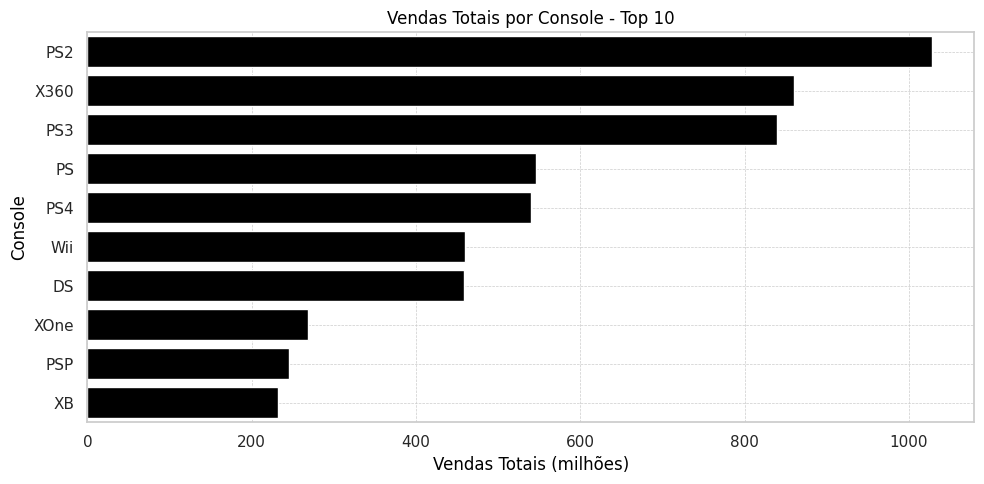


### 🔎 Análise

O console **PS2** lidera o ranking com um volume total acumulado de vendas de aproximadamente **1,03 bilhão**, seguido pelo **X360**, com cerca de **860 milhões**, e pelo **PS3**, que ocupa a terceira posição com **840 milhões**.

No final do Top 10, o console **XB** aparece com um total de vendas de aproximadamente **232 milhões**, um valor significativamente menor em comparação com os líderes.

Esses números demonstram a **dominância de certas plataformas** no mercado de jogos, refletindo sua **popularidade global e sucesso comercial ao longo do tempo**, enquanto também destacam consoles com menor alcance em termos de vendas acumuladas.


In [61]:
# 📊 Pergunta 3 - Análise de Vendas por Console

import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Formatação
def formatar_vendas(valor):
    if valor >= 1000:
        return f"{valor / 1000:.2f}".replace('.', ',') + " bilhão"
    else:
        return f"{valor:.0f}".replace('.', ',') + " milhões"

# Agrupamento e soma por console
consoles = df.groupby('console')['total_sales'].sum().sort_values(ascending=False).reset_index()
top10 = consoles.head(10)

# Exibir tabela
display(Markdown("### 📊 Top 10 Consoles com Maior Volume de Vendas Globais"))
display(top10)

# Gráfico em preto e branco
sns.set_palette("gray")
sns.barplot(x='total_sales', y='console', data=top10, color='black')
plt.xlabel('Vendas Totais (milhões)', color='black')
plt.ylabel('Console', color='black')
plt.title('Vendas Totais por Console - Top 10', color='black')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

# Análise Top 10 consoles por vendas acumuladas

p1 = top10.iloc[0]
p2 = top10.iloc[1]
p3 = top10.iloc[2]
ultimo = top10.iloc[9]

# Análise
texto = f"""
### 🔎 Análise

O console **{p1['console']}** lidera o ranking com um volume total acumulado de vendas de aproximadamente **{formatar_vendas(p1['total_sales'])}**, seguido pelo **{p2['console']}**, com cerca de **{formatar_vendas(p2['total_sales'])}**, e pelo **{p3['console']}**, que ocupa a terceira posição com **{formatar_vendas(p3['total_sales'])}**.

No final do Top 10, o console **{ultimo['console']}** aparece com um total de vendas de aproximadamente **{formatar_vendas(ultimo['total_sales'])}**, um valor significativamente menor em comparação com os líderes.

Esses números demonstram a **dominância de certas plataformas** no mercado de jogos, refletindo sua **popularidade global e sucesso comercial ao longo do tempo**, enquanto também destacam consoles com menor alcance em termos de vendas acumuladas.
"""
display(Markdown(texto))


## 📊 4. Qual é o desvio padrão das vendas por região (América do Norte, Europa e Japão)?

🎮 Esta análise compara as vendas de jogos nas regiões América do Norte, Europa e Japão.
O desvio padrão é usado para mostrar o quanto os valores de vendas variam dentro de cada região, indicando se as vendas dos jogos são mais próximas ou mais espalhadas em relação à média.

### 📊 Desvio Padrão das Vendas por Região

,Região,Desvio_Padrao
0,América do Norte,0.494787
1,Europa,0.392653
2,Japão,0.168811


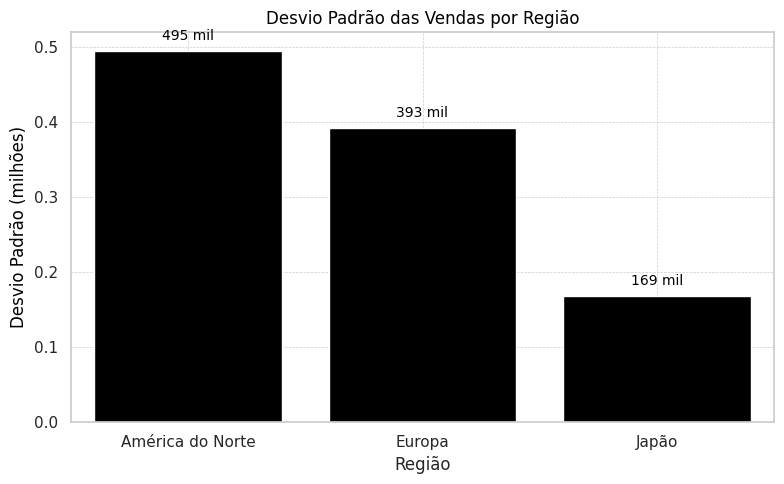


### 🔎 Análise

A **América do Norte** apresenta o maior desvio padrão nas vendas, com aproximadamente **495 mil**, indicando uma **alta variação nas vendas de jogos** nessa região — alguns jogos vendem muito, enquanto outros têm desempenho mais modesto.

A **Europa** aparece em segundo lugar, com um desvio padrão em torno de **393 mil**, o que sugere uma **variação moderada** entre os jogos vendidos na região.

Em contraste, o **Japão** possui o menor desvio padrão (**169 mil**), indicando que os jogos tendem a ter **vendas mais parecidas entre si**, com menor discrepância entre os jogos mais e menos vendidos.



In [63]:
# 📊 Pergunta 4 - Desvio Padrão das Vendas por Região

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

# Formatação valores no gráfico/análise
def formatar_valor_curto(valor):
    if valor < 1:
        return f"{valor * 1000:.0f} mil"
    else:
        return f"{valor:.2f}".replace('.', ',') + " milhões"

# Cálculo do desvio padrão
desvios = df[['na_sales', 'pal_sales', 'jp_sales']].std().reset_index()
desvios.columns = ['Região', 'Desvio_Padrao']
desvios['Região'] = desvios['Região'].replace({
    'na_sales': 'América do Norte',
    'pal_sales': 'Europa',
    'jp_sales': 'Japão'
})

# Exibe tabela
display(Markdown("### 📊 Desvio Padrão das Vendas por Região"))
display(desvios)

# Gráfico
sns.set_palette("gray")
grafico = sns.barplot(x='Região', y='Desvio_Padrao', data=desvios, color='black')

# Rótulos
for i, row in desvios.iterrows():
    grafico.text(i, row['Desvio_Padrao'] + 0.01, formatar_valor_curto(row['Desvio_Padrao']),
                 color='black', ha='center', va='bottom', fontsize=10)

plt.title('Desvio Padrão das Vendas por Região', color='black')
plt.ylabel('Desvio Padrão (milhões)', color='black')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

# Valores de desvio padrão por região
na = desvios.loc[desvios['Região'] == 'América do Norte', 'Desvio_Padrao'].values[0]
eu = desvios.loc[desvios['Região'] == 'Europa', 'Desvio_Padrao'].values[0]
jp = desvios.loc[desvios['Região'] == 'Japão', 'Desvio_Padrao'].values[0]

# Formatação
def formatar_valor_curto(valor):
    if valor < 1:
        return f"{valor * 1000:.0f} mil"
    else:
        return f"{valor:.2f}".replace('.', ',') + " milhões"

# Análise
texto = f"""
### 🔎 Análise

A **América do Norte** apresenta o maior desvio padrão nas vendas, com aproximadamente **{formatar_valor_curto(na)}**, indicando uma **alta variação nas vendas de jogos** nessa região — alguns jogos vendem muito, enquanto outros têm desempenho mais modesto.

A **Europa** aparece em segundo lugar, com um desvio padrão em torno de **{formatar_valor_curto(eu)}**, o que sugere uma **variação moderada** entre os jogos vendidos na região.

Em contraste, o **Japão** possui o menor desvio padrão (**{formatar_valor_curto(jp)}**), indicando que os jogos tendem a ter **vendas mais parecidas entre si**, com menor discrepância entre os jogos mais e menos vendidos.

"""
display(Markdown(texto))




## 📊 5. Como se distribuem as notas da crítica entre os 100 jogos mais vendidos?

🎮 Esta análise considera os 100 jogos com maior volume de vendas globais e observa como eles foram avaliados pela crítica.  
São analisadas medidas como mínimo, máximo, média e mediana, além da visualização da distribuição com um histograma e curva de densidade.

O objetivo é entender como a crítica avaliou os jogos de maior sucesso comercial, identificando se as notas se concentram em uma faixa específica ou se estão mais dispersas.


### 📊 Estatísticas das Notas da Crítica - Top 100

,Medida,Nota
0,Mínimo,5.900000
1,Máximo,10.000000
2,Média,8.650617
3,Mediana,8.700000


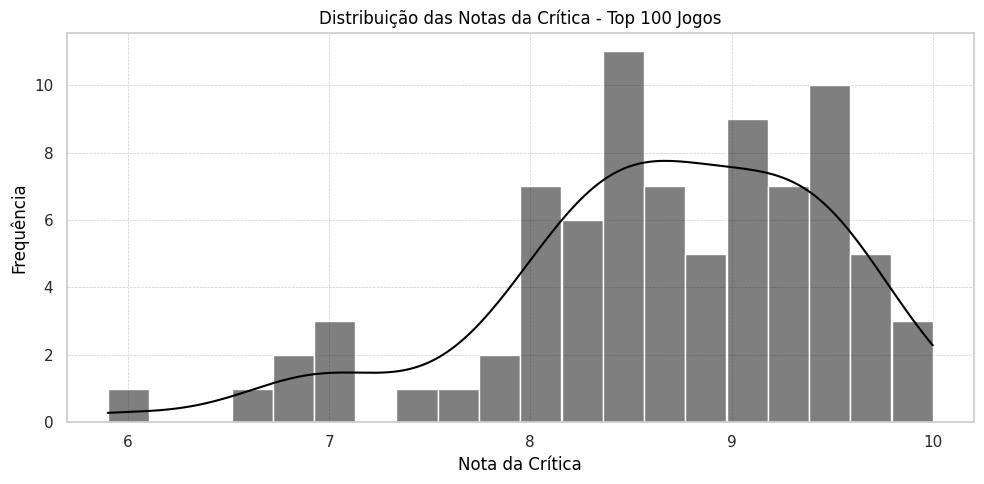


### 🔎 Análise

As notas da crítica dos 100 jogos mais vendidos variam entre **5.9** e **10.0**, com **média e mediana de 8.7**.  
Esses valores indicam que os títulos de maior desempenho comercial também tendem a ser **bem avaliados pela crítica especializada**, sugerindo uma possível **associação entre qualidade percebida e sucesso de vendas**.

A distribuição das notas mostra que a maioria dos jogos recebeu avaliações entre 8 e 9, o que indica que a crítica avaliou esses jogos de forma consistente e geralmente positiva.

Além disso, o fato de a **média e a mediana serem iguais** reforça a **simetria da distribuição**, indicando que as notas estão bem distribuídas em torno do centro, sem forte tendência de assimetria.


In [52]:
# 📊 Pergunta 5 - Distribuição das Notas da Crítica no Top 100

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Seleciona os 100 jogos mais vendidos
top100 = df.sort_values(by='total_sales', ascending=False).head(100)

# Filtra as notas da crítica válidas
notas = top100['critic_score'].dropna()

# Estatísticas principais
media = notas.mean()
mediana = notas.median()
minimo = notas.min()
maximo = notas.max()

# Exibe resumo estatístico
resumo = pd.DataFrame({
    'Medida': ['Mínimo', 'Máximo', 'Média', 'Mediana'],
    'Nota': [minimo, maximo, media, mediana]
})
display(Markdown("### 📊 Estatísticas das Notas da Crítica - Top 100"))
display(resumo)

# Histograma com curva de densidade
sns.histplot(notas, kde=True, bins=20, color='black')
plt.title('Distribuição das Notas da Crítica - Top 100 Jogos', color='black')
plt.xlabel('Nota da Crítica', color='black')
plt.ylabel('Frequência', color='black')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

# Análise
texto = f"""
### 🔎 Análise

As notas da crítica dos 100 jogos mais vendidos variam entre **{minimo:.1f}** e **{maximo:.1f}**, com **média e mediana de {media:.1f}**.
Esses valores indicam que os títulos de maior desempenho comercial também tendem a ser **bem avaliados pela crítica especializada**, sugerindo uma possível **associação entre qualidade percebida e sucesso de vendas**.

A distribuição das notas mostra que a maioria dos jogos recebeu avaliações entre 8 e 9, o que indica que a crítica avaliou esses jogos de forma consistente e geralmente positiva.

Além disso, o fato de a **média e a mediana serem iguais** reforça a **simetria da distribuição**, indicando que as notas estão bem distribuídas em torno do centro, sem forte tendência de assimetria.
"""
display(Markdown(texto))





## 📊 6. Quais distribuidoras concentram as maiores vendas entre os 100 jogos mais vendidos?

🎮 Esta análise considera apenas os 100 jogos com maior volume de vendas globais. A partir desse subconjunto, são identificadas as 10 distribuidoras que mais acumulam vendas totais, revelando quais editoras concentram os maiores sucessos comerciais do mercado.


### 📊 Top 10 Distribuidoras com Maior Volume de Vendas entre os 100 Jogos Mais Vendidos

,publisher,total_sales
0,Activision,254.87
1,Rockstar Games,160.78
2,Electronic Arts,89.09
3,EA Sports,67.94
4,Ubisoft,39.95
5,Bethesda Softworks,33.84
6,Sony Computer Entertainment,22.83
7,Microsoft Game Studios,20.57
8,Microsoft Studios,15.39
9,Square Enix,10.42


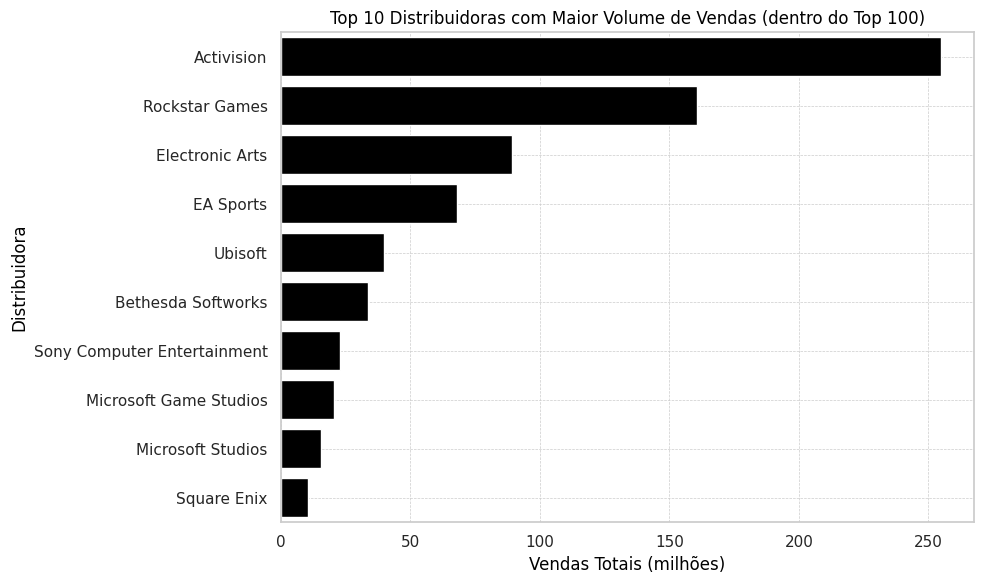


### 🔎 Análise

A distribuidora **Activision** lidera com um volume acumulado de vendas globais de aproximadamente **254,87 milhões** entre os 100 jogos mais vendidos, seguida por **Rockstar Games**, com cerca de **160,78 milhões**, e pela **Electronic Arts**, que ocupa a terceira posição com **89,09 milhões**.

Esses dados evidenciam a **capacidade dessas editoras em dominar o mercado**, lançando títulos altamente bem-sucedidos comercialmente, muitos deles pertencentes a franquias mundialmente conhecidas e consolidadas.

No extremo oposto do Top 10, a distribuidora **Square Enix** fecha a lista com um volume de vendas de **10,42 milhões**, o que, embora menor que os líderes, ainda representa uma presença relevante dentro do grupo mais lucrativo da indústria.



In [62]:
# 📊 Pergunta 6 - Quais distribuidoras concentram as maiores vendas entre os 100 jogos mais vendidos?

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Formatação
def formatar_milhoes(valor):
    return f"{valor:.2f}".replace('.', ',') + " milhões"

# Seleciona os 100 jogos mais vendidos
top100 = df.sort_values(by='total_sales', ascending=False).head(100)

# Agrupa por distribuidora e ordena
distribuidoras = top100.groupby('publisher')['total_sales'].sum().sort_values(ascending=False).reset_index()
top10 = distribuidoras.head(10)

# Tabela
display(Markdown("### 📊 Top 10 Distribuidoras com Maior Volume de Vendas entre os 100 Jogos Mais Vendidos"))
display(top10)

# Gráfico
sns.set_palette("gray")
sns.barplot(x='total_sales', y='publisher', data=top10, color='black')
plt.title('Top 10 Distribuidoras com Maior Volume de Vendas (dentro do Top 100)', color='black')
plt.xlabel('Vendas Totais (milhões)', color='black')
plt.ylabel('Distribuidora', color='black')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

# Análise 1º, 2º, 3º e 10º lugares
top1 = top10.iloc[0]
top2 = top10.iloc[1]
top3 = top10.iloc[2]
ultimo = top10.iloc[9]

# Análise
texto = f"""
### 🔎 Análise

A distribuidora **{top1['publisher']}** lidera com um volume acumulado de vendas globais de aproximadamente **{formatar_milhoes(top1['total_sales'])}** entre os 100 jogos mais vendidos, seguida por **{top2['publisher']}**, com cerca de **{formatar_milhoes(top2['total_sales'])}**, e pela **{top3['publisher']}**, que ocupa a terceira posição com **{formatar_milhoes(top3['total_sales'])}**.

Esses dados evidenciam a **capacidade dessas editoras em dominar o mercado**, lançando títulos altamente bem-sucedidos comercialmente, muitos deles pertencentes a franquias mundialmente conhecidas e consolidadas.

No extremo oposto do Top 10, a distribuidora **{ultimo['publisher']}** fecha a lista com um volume de vendas de **{formatar_milhoes(ultimo['total_sales'])}**, o que, embora menor que os líderes, ainda representa uma presença relevante dentro do grupo mais lucrativo da indústria.

"""
display(Markdown(texto))
